48000
12576000


/tmp/ipykernel_4150446/1756070015.py:16: RuntimeWarning: overflow encountered in scalar subtract
  audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1


Downsampling data by a factor of 1000...
(312, 12576000)
Downsampled array shape: (312, 12576)
Creating heatmap...


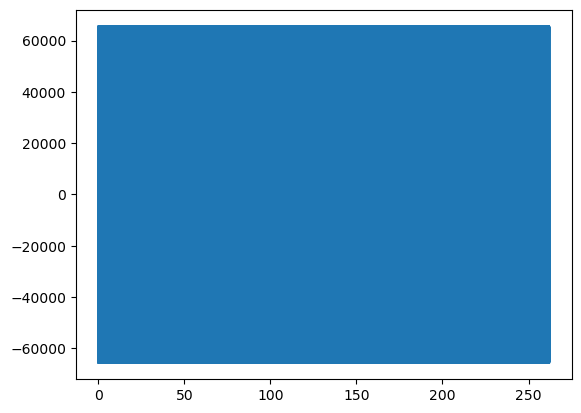

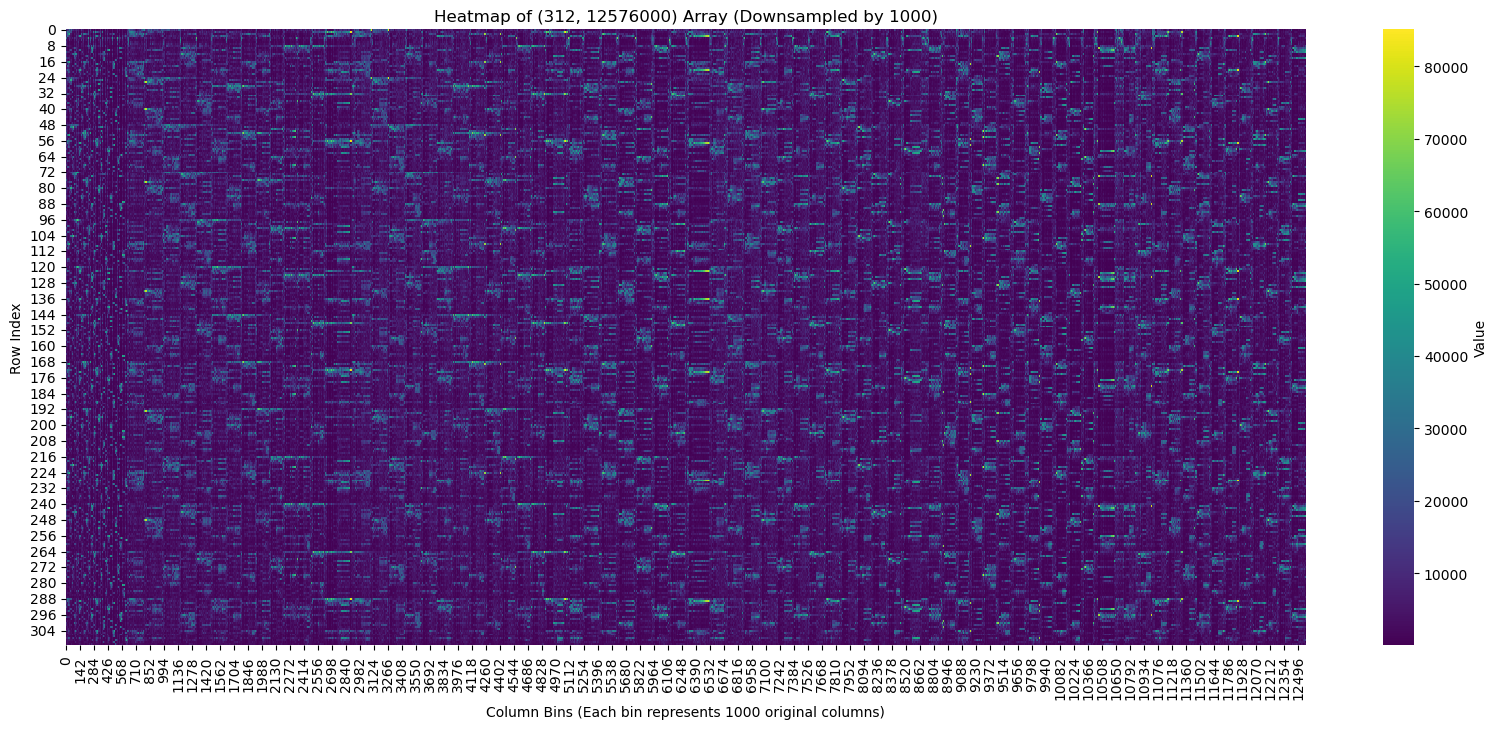

Heatmap displayed.
reshape data by a factor of 256...
(312, 12576000)
Reshaped the input data to  
(49125, 256, 312, 1)


In [ ]:
from scipy import io
from fretboard import FretBoard
import numpy
import matplotlib.pyplot as plt
import wave
from common import plot_heatmap,reshape_to_nn_input
sampleRate,input_signal_test=io.wavfile.read('../../../assets/testdata/E-G-A-B-chords.wav')
print(sampleRate)
filter=FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
audio_test=input_signal_test#[:,1];

audiomin=numpy.min(audio_test)
audiomax=numpy.max(audio_test)

audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1
print(len(audio_test))
nFrames =input_signal_test.shape[0]
time=numpy.linspace(0,len(audio_test)/sampleRate,len(audio_test))

plt.plot(time, audio_test, label='Input')

filterbank_out_test=numpy.zeros((numfilters,len(audio_test)))

filter.process(audio_test,filterbank_out_test)

plot_heatmap(filterbank_out_test)

nn_input_test=reshape_to_nn_input(filterbank_out_test)

In [1]:
from common import INPUT_SHAPE,OUTPUT_DIM_NOTES,OUTPUT_DIM_ONSETS
from model import build_cnn_model
print(nn_input_test.shape)
print(INPUT_SHAPE)
cnn_model=build_cnn_model(INPUT_SHAPE,OUTPUT_DIM_NOTES)
cnn_model.load_weights('/home/gmwangi/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/pure note model/guitarmidi-single-unnamed-output-final.weights.h5')
# dummy_filter_outputs_2d = nn_input_test.reshape(nn_input_test.shape[0],nn_input_test.shape[1],nn_input_test.shape[2])#np.random.rand(256, 288).astype(np.float32)

# print(dummy_filter_outputs_2d.shape)

# # Reshape for the model: (batch_size, time_steps, num_filters, channels)
# # For single inference, batch_size = 1, channels = 1
# input_for_model = np.expand_dims(dummy_filter_outputs_2d[int(200000/256)], axis=0)  # Add batch dimension

# print(input_for_model.shape)
# input_for_model = np.expand_dims(input_for_model, axis=-1) # Add channel dimension

# print(input_for_model.shape)
outsample=710000
predictions_cnn = cnn_model.predict(nn_input_test[range(int(outsample/256),int((outsample+1000)/256))], verbose=0)

# print(predictions_cnn)
xpred=range(1,len(predictions_cnn))
print(len(predictions_cnn))
print(predictions_cnn[0].shape)
plt.plot(predictions_cnn[0])
plt.show()
# plt.plot(nn_output[int(outsample/256)])

2025-07-08 07:33:38.040277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751952818.054223   20778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751952818.058552   20778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751952818.069758   20778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751952818.069771   20778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751952818.069773   20778 computation_placer.cc:177] computation placer alr

NameError: name 'nn_input_test' is not defined